# Dataset Overview

In [7]:
from pathlib import Path
import pandas as pd

# Load the dataset
DATA_PATH = Path("data/cleaned_dataset/Hotel_dataset.csv") # เปลี่ยนได้ถ้ารันไม่ได้
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing dataset at {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

date_cols = [col for col in df.columns if "date" in col.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

# Dataset Overview
print("=== DATASET OVERVIEW ===")
print(f"Dataset Source: {DATA_PATH}")
print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Date Columns : {len(date_cols)} ({', '.join(date_cols) if date_cols else 'None'})")

print("\n=== COLUMN SUMMARY ===")
column_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Non-Null Count': df.notna().sum(),
    'Null Count': df.isna().sum(),
    'Unique Values': df.nunique()
})
print(column_info.to_string(index=False))

print("\n=== SAMPLE DATA (First 5 Rows) ===")
print(df.head().to_string())

print("\n=== BASIC STATISTICS (Numeric Columns) ===")
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print(df[numeric_cols].describe().round(2).to_string())
else:
    print("No numeric columns found.")

print("\n=== BASIC STATISTICS (Categorical Columns) ===")
cat_cols = df.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    for col in cat_cols[:5]:  # บอก column เเค่ 5 อันแรก
        print(f"\n{col}:")
        print(df[col].value_counts().head().to_string())
        if len(df[col].value_counts()) > 5:
            print(f"... and {len(df[col].value_counts()) - 5} more unique values")
else:
    print("No categorical columns found.")

=== DATASET OVERVIEW ===
Dataset Source: data\cleaned_dataset\Hotel_dataset.csv
Total Rows: 5,000
Total Columns: 12
Memory Usage: 1.35 MB
Date Columns : 2 (booking_date, check_in_date)

=== COLUMN SUMMARY ===
                 Column      Data Type  Non-Null Count  Null Count  Unique Values
             booking_id            str            5000           0           5000
           booking_date datetime64[us]            5000           0            729
          check_in_date datetime64[us]            5000           0            796
             channel_id            str            5000           0              4
           rate_code_id            str            5000           0              4
             rooms_sold          int64            5000           0              3
     gross_room_revenue        float64            5000           0           4900
                 status            str            5000           0              3
      is_commissionable           bool            500

C:\Users\User\AppData\Local\Temp\ipykernel_11456\3839169307.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


# Data Quality Check

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

DATA_PATH = Path("C:/cygwin64/home/BestyBest/hotel_business_owner-s_dilemma_DA/data/cleaned_dataset/Hotel_dataset.csv") # เปลี่ยนได้ถ้ารันไม่ได้

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing dataset at {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

# Auto-parse columns that look like dates
date_cols = [col for col in df.columns if "date" in col.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
df.head()


Rows: 5,000 | Columns: 12


,booking_id,booking_date,check_in_date,channel_id,rate_code_id,rooms_sold,gross_room_revenue,status,is_commissionable,default_commission_rate,commission_amount,net_room_revenue
0,BK_00000,2026-10-17,2026-11-01,CH_OTA_BKG,CORP,1,173.75,Checked-Out,True,0.18,31.275,142.475
1,BK_00001,2025-04-15,2025-07-11,CH_OTA_BKG,NET,1,92.51,Confirmed,False,0.18,0.000,92.510
2,BK_00002,2025-08-27,2025-10-31,CH_OTA_BKG,PROMO,3,1058.85,Checked-Out,True,0.18,190.593,868.257
3,BK_00003,2026-03-06,2026-04-04,CH_WHOLE,CORP,1,398.70,Confirmed,True,0.00,0.000,398.700
4,BK_00004,2026-12-16,2027-02-09,CH_DIRECT,CORP,1,170.43,Cancelled,True,0.00,0.000,170.430


In [8]:
# Basic schema and missing-value overview
df.info()

sample_values = df.apply(lambda s: s.dropna().unique()[:3], axis=0)
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
    "sample_values": sample_values.apply(lambda v: ", ".join(map(str, v))),
}).sort_values(by="missing", ascending=False)

display(summary)

duplicate_rows = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_rows:,}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   booking_id               5000 non-null   object        
 1   booking_date             5000 non-null   datetime64[ns]
 2   check_in_date            5000 non-null   datetime64[ns]
 3   channel_id               5000 non-null   object        
 4   rate_code_id             5000 non-null   object        
 5   rooms_sold               5000 non-null   int64         
 6   gross_room_revenue       5000 non-null   float64       
 7   status                   5000 non-null   object        
 8   is_commissionable        5000 non-null   bool          
 9   default_commission_rate  5000 non-null   float64       
 10  commission_amount        5000 non-null   float64       
 11  net_room_revenue         5000 non-null   float64       
dtypes: bool(1), datetime64[ns](2), flo

,dtype,missing,missing_pct,n_unique,sample_values
booking_id,object,0,0.0,5000,"BK_00000, BK_00001, BK_00002"
booking_date,datetime64[ns],0,0.0,729,"2026-10-17 00:00:00, 2025-04-15 00:00:00, 2025..."
check_in_date,datetime64[ns],0,0.0,796,"2026-11-01 00:00:00, 2025-07-11 00:00:00, 2025..."
channel_id,object,0,0.0,4,"CH_OTA_BKG, CH_WHOLE, CH_DIRECT"
rate_code_id,object,0,0.0,4,"CORP, NET, PROMO"
rooms_sold,int64,0,0.0,3,"1, 3, 2"
gross_room_revenue,float64,0,0.0,4900,"173.75, 92.51, 1058.85"
status,object,0,0.0,3,"Checked-Out, Confirmed, Cancelled"
is_commissionable,bool,0,0.0,2,"True, False"
default_commission_rate,float64,0,0.0,3,"0.18, 0.0, 0.15"


Duplicate rows: 0


In [9]:
# Numeric checks: distribution, negatives, and outliers
numeric_cols = df.select_dtypes(include="number").columns

if len(numeric_cols) == 0:
    print("No numeric columns found.")
else:
    display(df[numeric_cols].describe().T)

    negative_counts = (df[numeric_cols] < 0).sum().sort_values(ascending=False)
    display(pd.DataFrame({"negative_count": negative_counts}))

    outlier_rows = []
    for col in numeric_cols:
        series = df[col].dropna()
        if series.empty:
            continue
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = ((series < lower) | (series > upper)).sum()
        outlier_rows.append({
            "column": col,
            "outlier_count": int(outliers),
            "outlier_pct": round(outliers / len(series) * 100, 2),
            "min": series.min(),
            "max": series.max(),
        })

    if outlier_rows:
        display(pd.DataFrame(outlier_rows).sort_values(by="outlier_count", ascending=False))

,count,mean,std,min,25%,50%,75%,max
rooms_sold,5000.0,2.000600,0.818495,1.0000,1.000,2.000,3.0000,3.0000
gross_room_revenue,5000.0,578.826806,352.859140,80.0100,299.085,477.315,814.7175,1495.1300
default_commission_rate,5000.0,0.083682,0.083312,0.0000,0.000,0.150,0.1800,0.1800
commission_amount,5000.0,35.672066,58.043867,0.0000,0.000,0.000,58.5240,266.9364
net_room_revenue,5000.0,543.154740,336.803055,68.0085,276.910,451.085,755.8350,1495.1300


,negative_count
rooms_sold,0
gross_room_revenue,0
default_commission_rate,0
commission_amount,0
net_room_revenue,0


,column,outlier_count,outlier_pct,min,max
3,commission_amount,358,7.16,0.0000,266.9364
4,net_room_revenue,26,0.52,68.0085,1495.1300
0,rooms_sold,0,0.00,1.0000,3.0000
2,default_commission_rate,0,0.00,0.0000,0.1800
1,gross_room_revenue,0,0.00,80.0100,1495.1300


In [10]:
# Categorical and date checks
cat_cols = df.select_dtypes(include=["object", "category", "bool", "string"]).columns

if len(cat_cols) == 0:
    print("No categorical columns found.")
else:
    cat_rows = []
    whitespace_rows = []
    for col in cat_cols:
        series = df[col]
        value_counts = series.value_counts(dropna=True)
        top_value = value_counts.index[0] if not value_counts.empty else None
        top_freq = int(value_counts.iloc[0]) if not value_counts.empty else 0
        cat_rows.append({
            "column": col,
            "n_unique": int(series.nunique(dropna=True)),
            "missing": int(series.isna().sum()),
            "top_value": top_value,
            "top_freq": top_freq,
        })

        text = series.dropna().astype(str)
        stripped = text.str.strip()
        whitespace_rows.append({
            "column": col,
            "empty_or_whitespace": int((stripped == "").sum()),
            "leading_trailing_ws": int((stripped != text).sum()),
        })

    display(pd.DataFrame(cat_rows).sort_values(by="n_unique", ascending=False))
    display(pd.DataFrame(whitespace_rows).sort_values(by="leading_trailing_ws", ascending=False))

if date_cols:
    today = pd.Timestamp.today().normalize()
    date_summary = []
    for col in date_cols:
        series = df[col]
        date_summary.append({
            "column": col,
            "min": series.min(),
            "max": series.max(),
            "missing": int(series.isna().sum()),
            "future_dates": int((series > today).sum()),
        })

    display(pd.DataFrame(date_summary))

# Simple consistency checks if common fields exist
checks = {}
if {"booking_date", "check_in_date"}.issubset(df.columns):
    checks["check_in_before_booking"] = int((df["check_in_date"] < df["booking_date"]).sum())
if {"check_in_date", "check_out_date"}.issubset(df.columns):
    checks["check_out_before_check_in"] = int((df["check_out_date"] < df["check_in_date"]).sum())

if checks:
    display(pd.DataFrame([checks]))


,column,n_unique,missing,top_value,top_freq
0,booking_id,5000,0,BK_04999,1
1,channel_id,4,0,CH_OTA_BKG,1287
2,rate_code_id,4,0,PROMO,1295
3,status,3,0,Cancelled,1703
4,is_commissionable,2,0,True,3749


,column,empty_or_whitespace,leading_trailing_ws
0,booking_id,0,0
1,channel_id,0,0
2,rate_code_id,0,0
3,status,0,0
4,is_commissionable,0,0


,column,min,max,missing,future_dates
0,booking_date,2025-01-01,2026-12-31,0,1783
1,check_in_date,2025-01-03,2027-03-28,0,2100


,check_in_before_booking
0,0


# Descriptive Statistics

In [14]:
# Descriptive Statistics
import numpy as np

# For numeric columns
if len(numeric_cols) > 0:
    print("\n--- Numeric Columns ---")
    desc_numeric = df[numeric_cols].describe()
    print(desc_numeric.round(2).to_string())

    # Additional statistics
    print("\nSkewness:")
    print(df[numeric_cols].skew().round(2).to_string())

    print("\nKurtosis:")
    print(df[numeric_cols].kurtosis().round(2).to_string())

    print("\nCoefficient of Variation (CV):")
    cv = (df[numeric_cols].std() / df[numeric_cols].mean()).abs()
    print(cv.round(2).to_string())

else:
    print("No numeric columns found.")

# For categorical columns
if len(cat_cols) > 0:
    print("\n--- Categorical Columns ---")
    for col in cat_cols:
        print(f"\n{col}:")
        print(f"  Mode: {df[col].mode().iloc[0] if not df[col].mode().empty else 'N/A'}")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Most frequent value count: {df[col].value_counts().max()}")
        print(f"  Least frequent value count: {df[col].value_counts().min()}")

else:
    print("No categorical columns found.")

# For date columns
if date_cols:
    print("\n--- Date Columns ---")
    for col in date_cols:
        print(f"\n{col}:")
        print(f"  Min: {df[col].min()}")
        print(f"  Max: {df[col].max()}")
        print(f"  Range: {(df[col].max() - df[col].min()).days} days")



--- Numeric Columns ---
       rooms_sold  gross_room_revenue  default_commission_rate  commission_amount  net_room_revenue
count     5000.00             5000.00                  5000.00            5000.00           5000.00
mean         2.00              578.83                     0.08              35.67            543.15
std          0.82              352.86                     0.08              58.04            336.80
min          1.00               80.01                     0.00               0.00             68.01
25%          1.00              299.09                     0.00               0.00            276.91
50%          2.00              477.32                     0.15               0.00            451.08
75%          3.00              814.72                     0.18              58.52            755.84
max          3.00             1495.13                     0.18             266.94           1495.13

Skewness:
rooms_sold                -0.00
gross_room_revenue         0.78


# Univariate Analysis

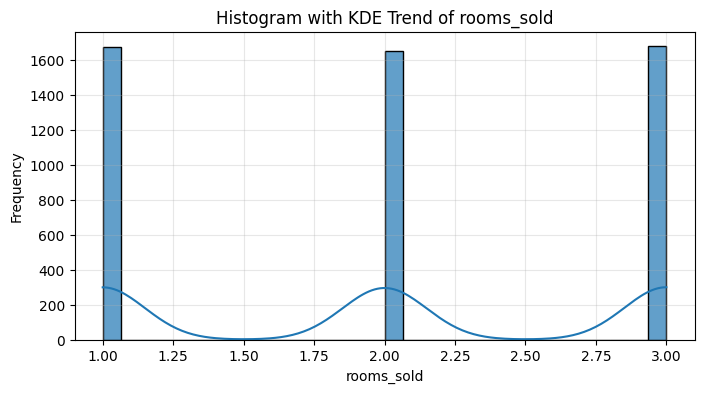

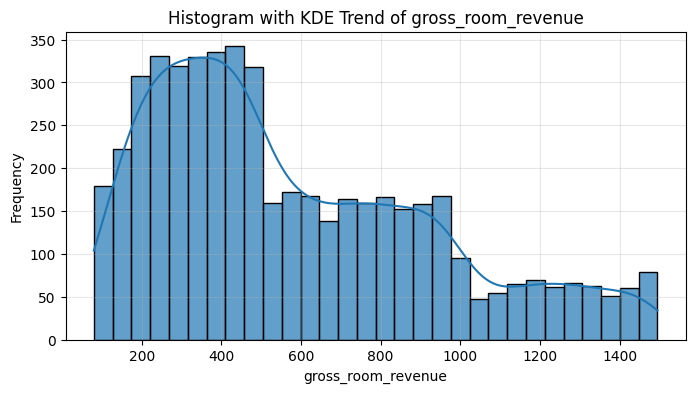

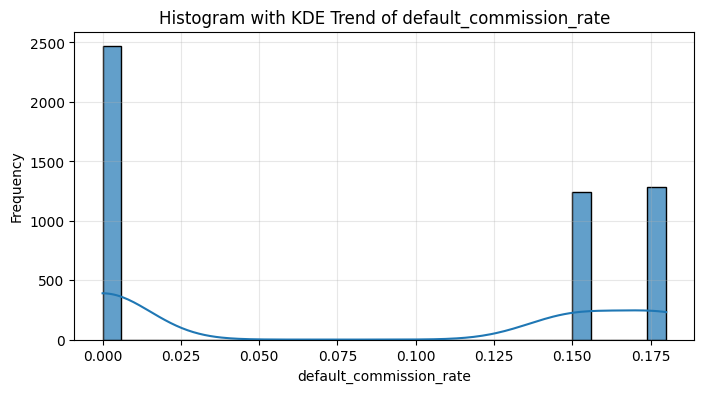

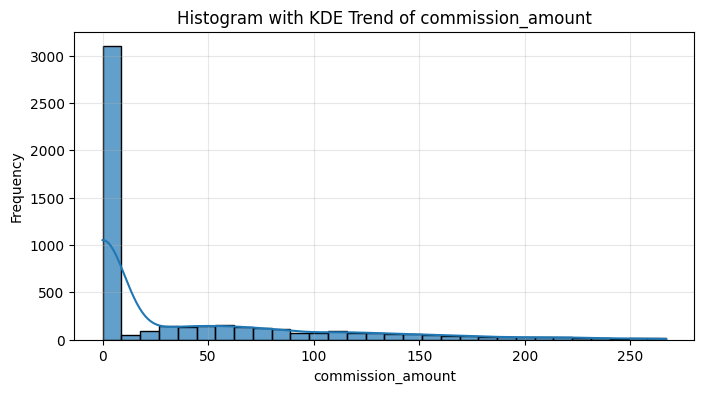

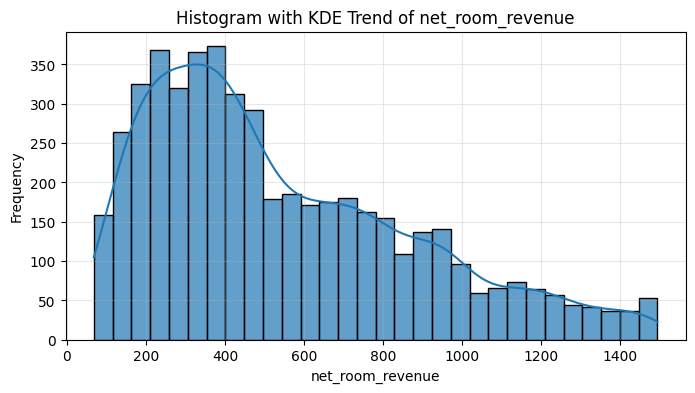

In [ ]:
# Univariate Analysis
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create result folder
result_dir = "data/result"
os.makedirs(result_dir, exist_ok=True)

# Histograms for numeric columns (first 5) with KDE trend line
if len(numeric_cols) > 0:
    for i, col in enumerate(numeric_cols[:5]):
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col].dropna(), bins=30, alpha=0.7, edgecolor='black', kde=True)
        plt.title(f'Histogram with KDE Trend of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        plt.savefig(f"{result_dir}/{col}_histogram.png")
        plt.show()
        if i >= 4:  
            break
# รูปจะโดนเก็บไว้ใน data/result/ เผื่อได้ใช้ตอนเเปะนะจ๊ะ ถ้าคิดว่าไม่ได้ใช้ก็ลบออกได้เลยนะจ๊ะ

# Bivariate Analysis

C:\Users\User\AppData\Local\Temp\ipykernel_11456\3813788416.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


=== CORRELATION MATRIX ===
                         rooms_sold  gross_room_revenue  default_commission_rate  commission_amount  net_room_revenue
rooms_sold                    1.000               0.669                   -0.001              0.253             0.657
gross_room_revenue            0.669               1.000                   -0.015              0.353             0.987
default_commission_rate      -0.001              -0.015                    1.000              0.612            -0.122
commission_amount             0.253               0.353                    0.612              1.000             0.197
net_room_revenue              0.657               0.987                   -0.122              0.197             1.000


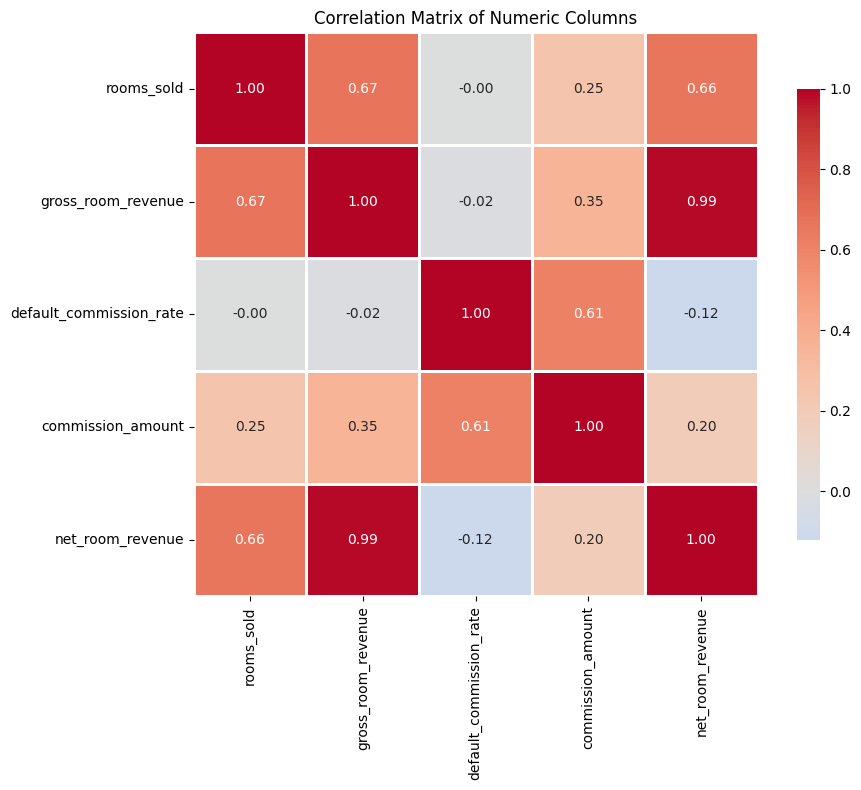


=== TOP CORRELATED PAIRS ===
                   var1                    var2  correlation
     gross_room_revenue        net_room_revenue     0.986910
             rooms_sold      gross_room_revenue     0.668834
             rooms_sold        net_room_revenue     0.657186
default_commission_rate       commission_amount     0.612450
     gross_room_revenue       commission_amount     0.352574
             rooms_sold       commission_amount     0.252605
      commission_amount        net_room_revenue     0.197045
default_commission_rate        net_room_revenue     0.121719
     gross_room_revenue default_commission_rate     0.015435
             rooms_sold default_commission_rate     0.000912


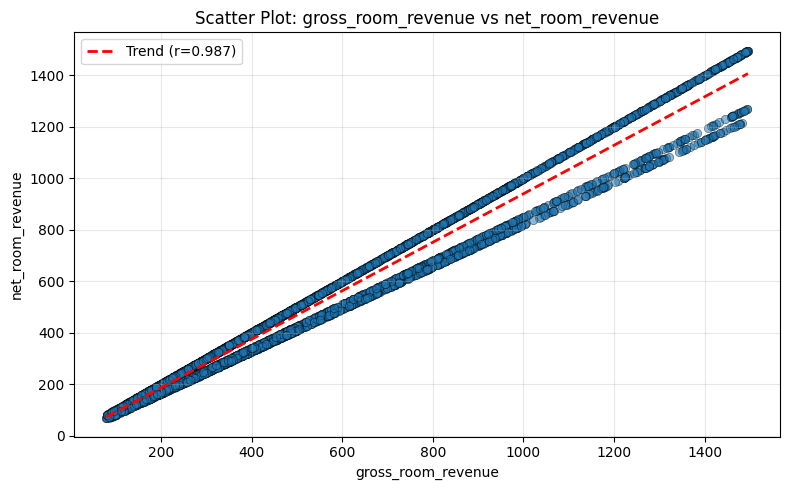

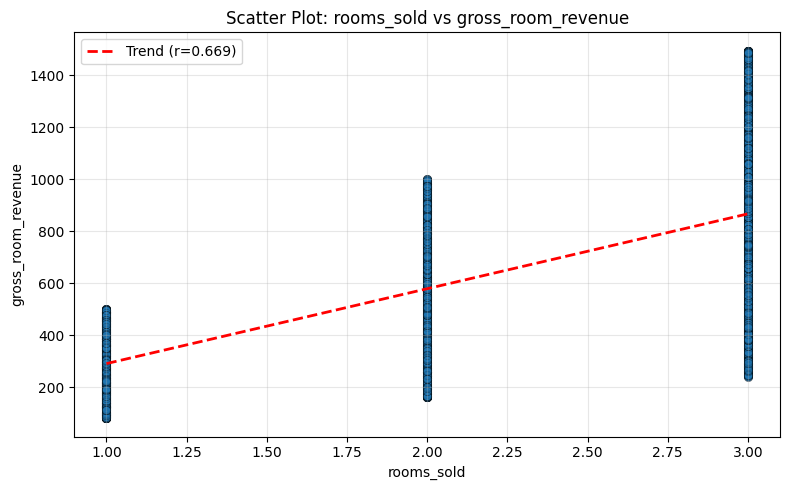

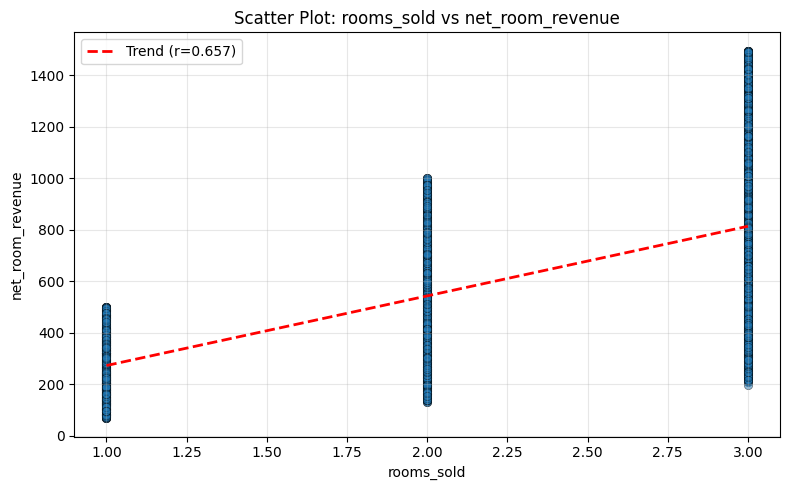

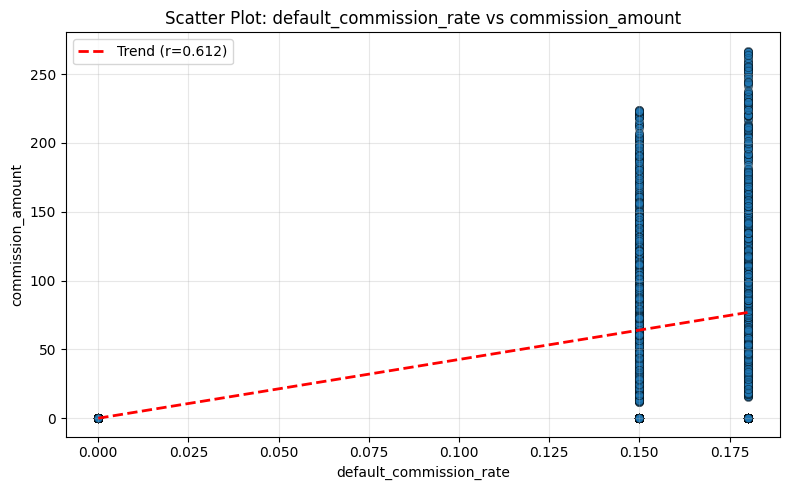

In [5]:
# Bivariate Analysis - Numeric vs Numeric
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path

# Load data if not already loaded
try:
    df
except NameError:
    DATA_PATH = Path("data/cleaned_dataset/Hotel_dataset.csv")
    if not DATA_PATH.exists():
        raise FileNotFoundError(f"Missing dataset at {DATA_PATH.resolve()}")
    df = pd.read_csv(DATA_PATH)
    date_cols = [col for col in df.columns if "date" in col.lower()]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

# Setup result directory
result_dir = "data/result"
import os
os.makedirs(result_dir, exist_ok=True)

# Ensure variables are defined
numeric_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Correlation Matrix
if len(numeric_cols) > 1:
    print("=== CORRELATION MATRIX ===")
    corr_matrix = df[numeric_cols].corr()
    print(corr_matrix.round(3).to_string())
    
    # Visualization of correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Numeric Columns')
    plt.tight_layout()
    plt.savefig(f"{result_dir}/correlation_matrix.png", dpi=100, bbox_inches='tight')
    plt.show()

# Scatter plots for top correlated pairs
if len(numeric_cols) > 1:
    print("\n=== TOP CORRELATED PAIRS ===")
    
    # Get correlations excluding diagonal
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'correlation': abs(corr_matrix.iloc[i, j])
            })
    
    corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('correlation', ascending=False)
    print(corr_pairs_df.head(10).to_string(index=False))
    
    # Plot top 4 correlations
    for idx, row in corr_pairs_df.head(4).iterrows():
        var1, var2 = row['var1'], row['var2']
        
        plt.figure(figsize=(8, 5))
        plt.scatter(df[var1].dropna(), df[var2].dropna(), alpha=0.5, edgecolors='k', linewidth=0.5)
        
        # Add trend line
        z = np.polyfit(df[var1].dropna(), df[var2].dropna(), 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[var1].min(), df[var1].max(), 100)
        plt.plot(x_line, p(x_line), "r--", linewidth=2, label=f'Trend (r={row["correlation"]:.3f})')
        
        plt.xlabel(var1)
        plt.ylabel(var2)
        plt.title(f'Scatter Plot: {var1} vs {var2}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{result_dir}/{var1}_vs_{var2}_scatter.png", dpi=100, bbox_inches='tight')
        plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_11456\1501781018.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


=== NUMERIC vs CATEGORICAL (Box Plots) ===


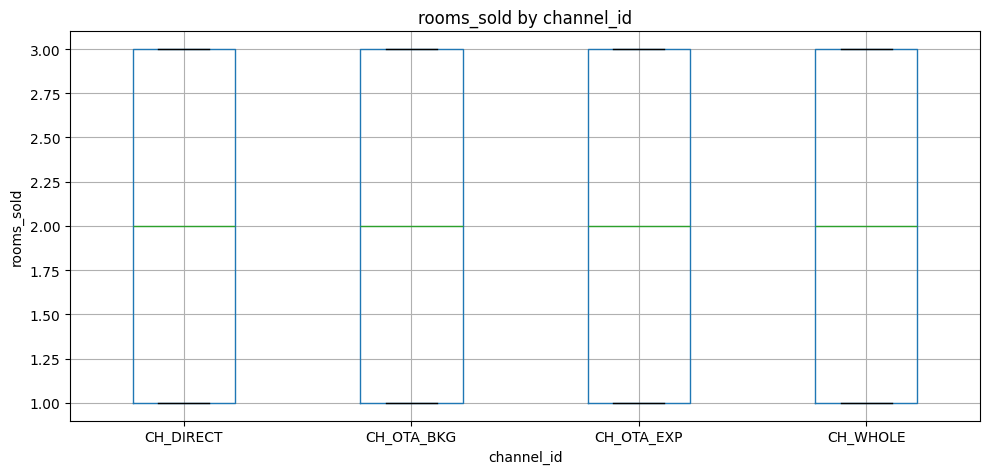

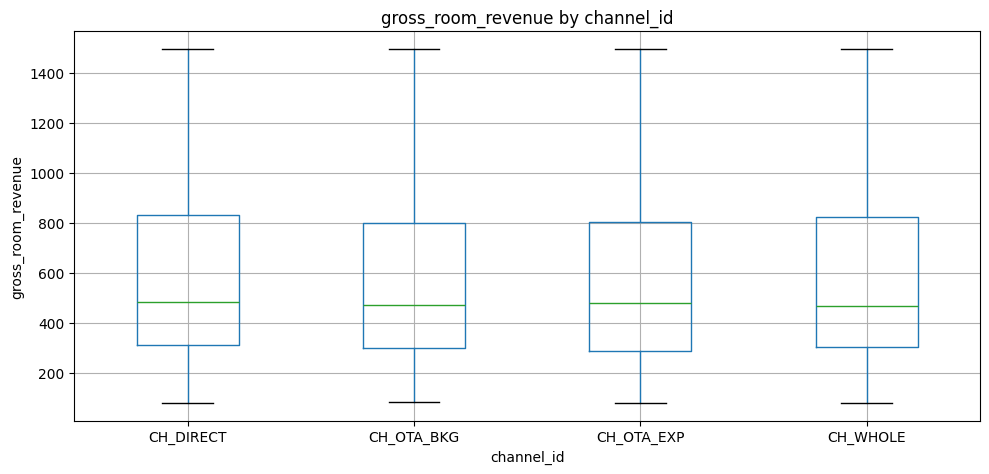

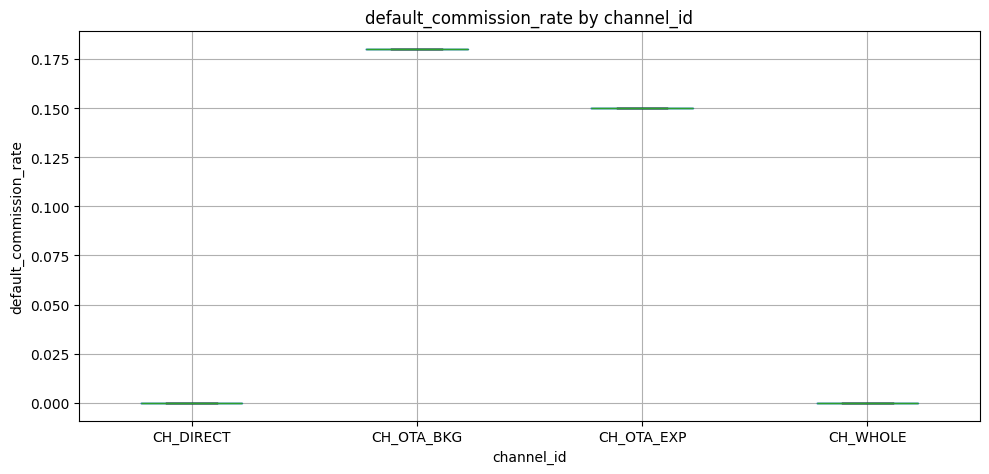

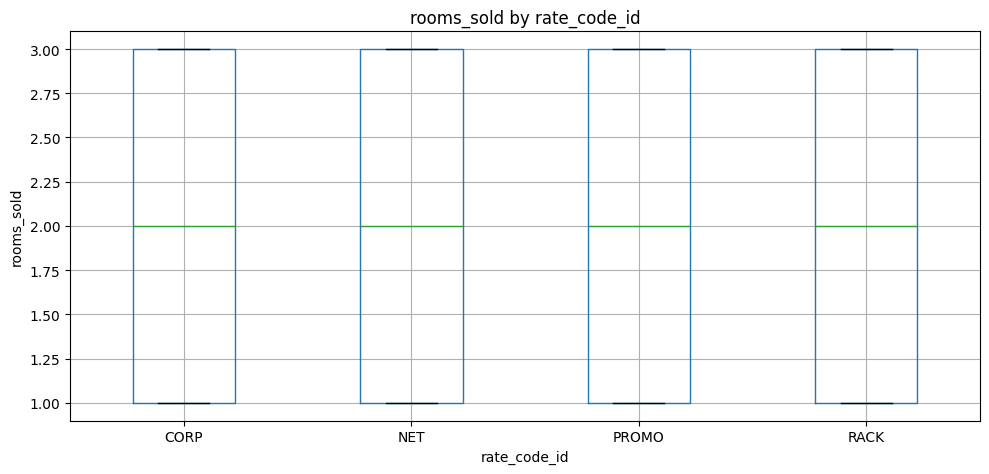

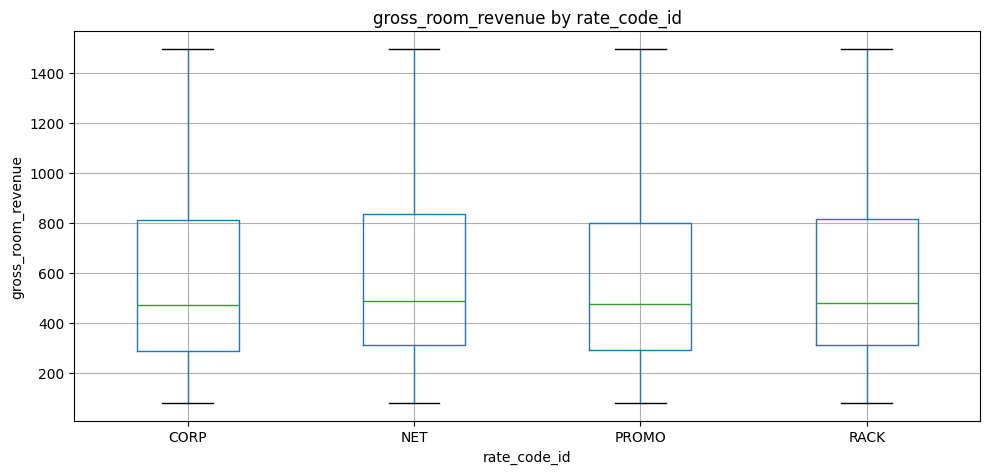

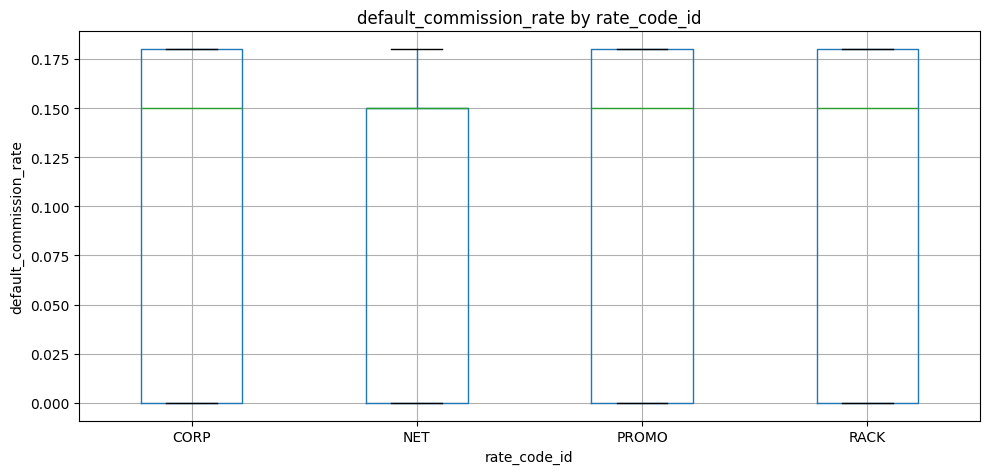

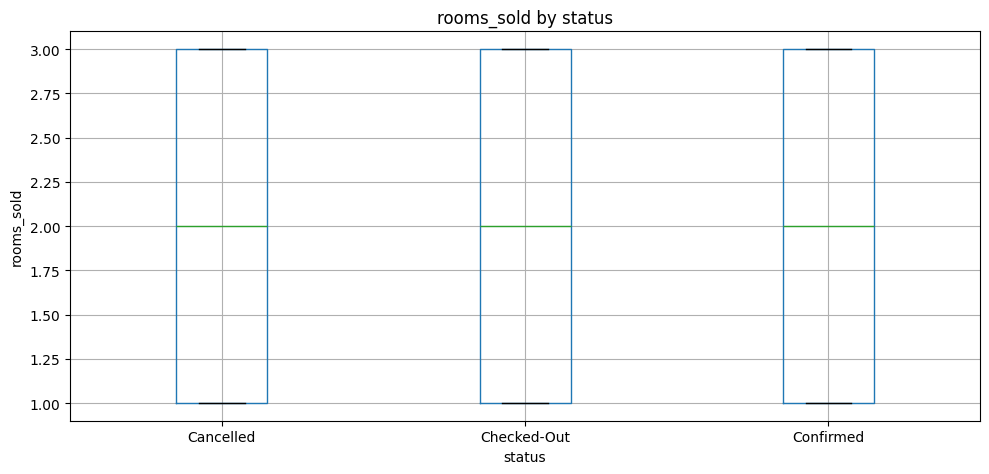

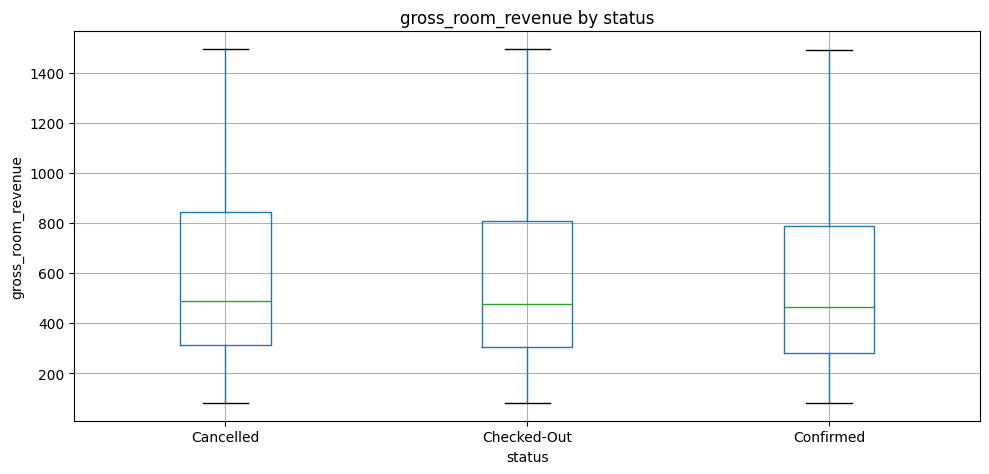

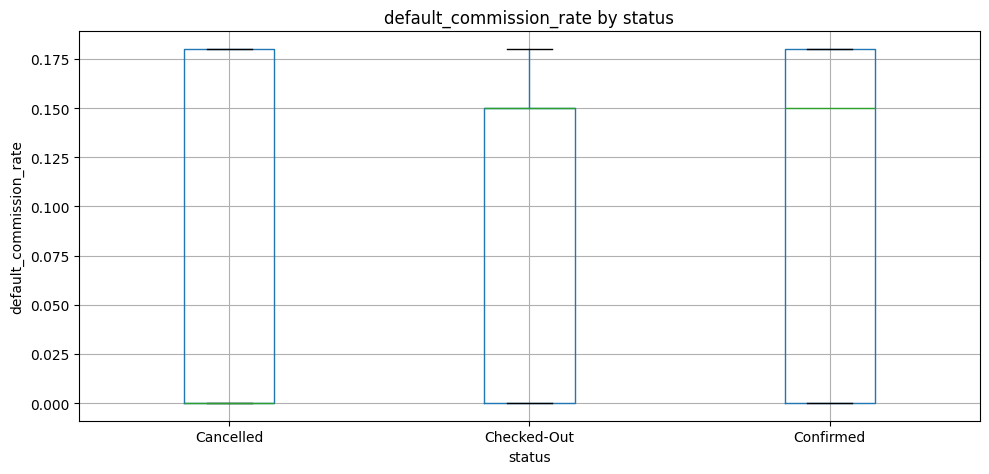


=== CATEGORICAL vs CATEGORICAL (Cross-Tabulation) ===

Cross-tabulation: channel_id vs rate_code_id
rate_code_id  CORP   NET  PROMO  RACK   All
channel_id                                 
CH_DIRECT      292   307    308   301  1208
CH_OTA_BKG     328   308    325   326  1287
CH_OTA_EXP     280   322    327   316  1245
CH_WHOLE       306   314    335   305  1260
All           1206  1251   1295  1248  5000


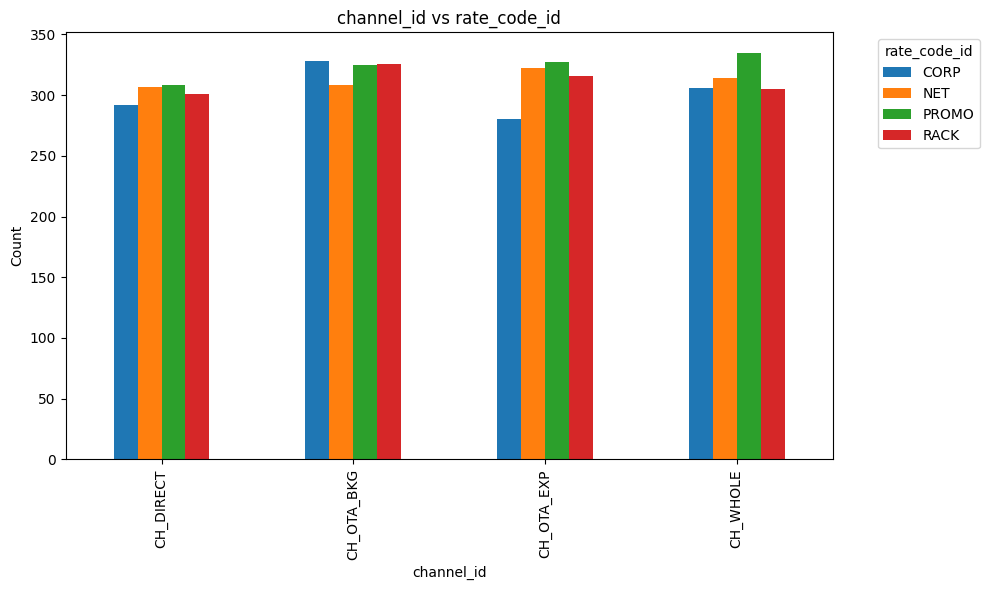


Cross-tabulation: channel_id vs status
status      Cancelled  Checked-Out  Confirmed   All
channel_id                                         
CH_DIRECT         409          393        406  1208
CH_OTA_BKG        439          417        431  1287
CH_OTA_EXP        408          443        394  1245
CH_WHOLE          447          420        393  1260
All              1703         1673       1624  5000


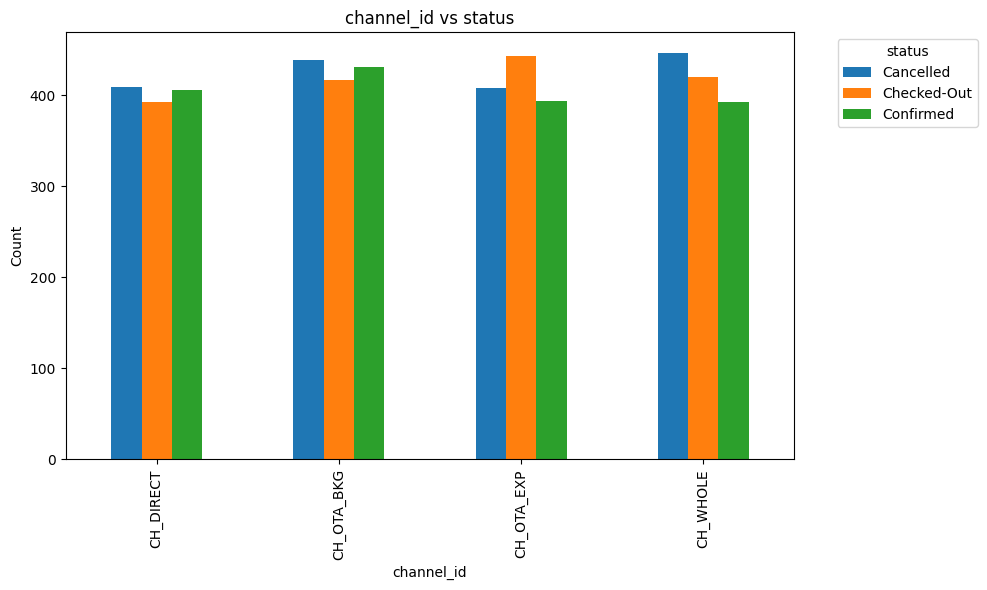


Cross-tabulation: rate_code_id vs status
status        Cancelled  Checked-Out  Confirmed   All
rate_code_id                                         
CORP                406          407        393  1206
NET                 425          413        413  1251
PROMO               467          428        400  1295
RACK                405          425        418  1248
All                1703         1673       1624  5000


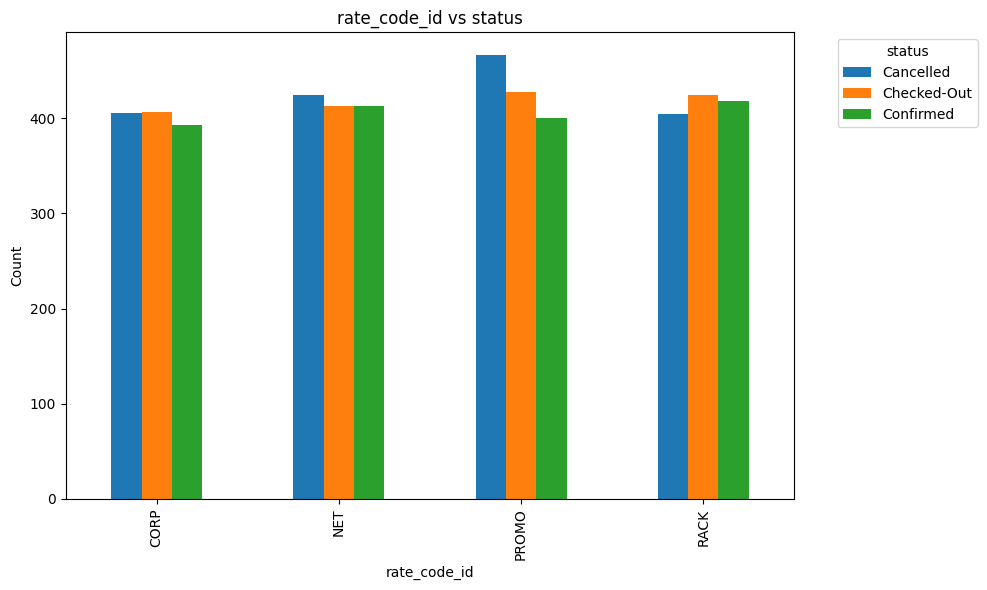

In [6]:
# Bivariate Analysis - Numeric vs Categorical & Categorical vs Categorical
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Load data if not already loaded
try:
    df
except NameError:
    DATA_PATH = Path("data/cleaned_dataset/Hotel_dataset.csv")
    if not DATA_PATH.exists():
        raise FileNotFoundError(f"Missing dataset at {DATA_PATH.resolve()}")
    df = pd.read_csv(DATA_PATH)
    date_cols = [col for col in df.columns if "date" in col.lower()]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

# Setup result directory
result_dir = "data/result"
import os
os.makedirs(result_dir, exist_ok=True)

# Ensure variables are defined
numeric_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

if len(numeric_cols) > 0 and len(cat_cols) > 0:
    print("=== NUMERIC vs CATEGORICAL (Box Plots) ===")
    
    # Limit categorical columns to first 3 with fewer than 10 unique values
    cat_cols_filtered = [col for col in cat_cols if df[col].nunique() < 10][:3]
    
    if cat_cols_filtered:
        for cat_col in cat_cols_filtered:
            for i, num_col in enumerate(numeric_cols[:3]):  # Top 3 numeric columns
                plt.figure(figsize=(10, 5))
                df.boxplot(column=num_col, by=cat_col, ax=plt.gca())
                plt.title(f'{num_col} by {cat_col}')
                plt.suptitle('')  # Remove default title
                plt.xlabel(cat_col)
                plt.ylabel(num_col)
                plt.tight_layout()
                plt.savefig(f"{result_dir}/{num_col}_by_{cat_col}_boxplot.png", dpi=100, bbox_inches='tight')
                plt.show()
                if i >= 2:  # Limit plots per category
                    break

# Bivariate Analysis - Categorical vs Categorical
if len(cat_cols) > 1:
    print("\n=== CATEGORICAL vs CATEGORICAL (Cross-Tabulation) ===")
    
    cat_cols_filtered = [col for col in cat_cols if df[col].nunique() < 10]
    
    if len(cat_cols_filtered) >= 2:
        for i, cat1 in enumerate(cat_cols_filtered[:3]):
            for cat2 in cat_cols_filtered[i+1:3]:
                print(f"\nCross-tabulation: {cat1} vs {cat2}")
                cross_tab = pd.crosstab(df[cat1], df[cat2], margins=True)
                print(cross_tab.to_string())
                
                # Visualization
                plt.figure(figsize=(10, 6))
                cross_tab_no_margins = pd.crosstab(df[cat1], df[cat2])
                cross_tab_no_margins.plot(kind='bar', ax=plt.gca())
                plt.title(f'{cat1} vs {cat2}')
                plt.xlabel(cat1)
                plt.ylabel('Count')
                plt.legend(title=cat2, bbox_to_anchor=(1.05, 1), loc='upper left')
                plt.tight_layout()
                plt.savefig(f"{result_dir}/{cat1}_vs_{cat2}_crosstab.png", dpi=100, bbox_inches='tight')
                plt.show()

# multivariate analysis


=== MULTIVARIATE ANALYSIS (5 numeric variables) ===

1. CORRELATION ANALYSIS
--------------------------------------------------

Correlation Matrix:
                         rooms_sold  gross_room_revenue  default_commission_rate  commission_amount  net_room_revenue
rooms_sold                    1.000               0.669                   -0.001              0.253             0.657
gross_room_revenue            0.669               1.000                   -0.015              0.353             0.987
default_commission_rate      -0.001              -0.015                    1.000              0.612            -0.122
commission_amount             0.253               0.353                    0.612              1.000             0.197
net_room_revenue              0.657               0.987                   -0.122              0.197             1.000

Strong Correlations (|r| > 0.5):
             Variable 1         Variable 2  Correlation
     gross_room_revenue   net_room_revenue     0.986

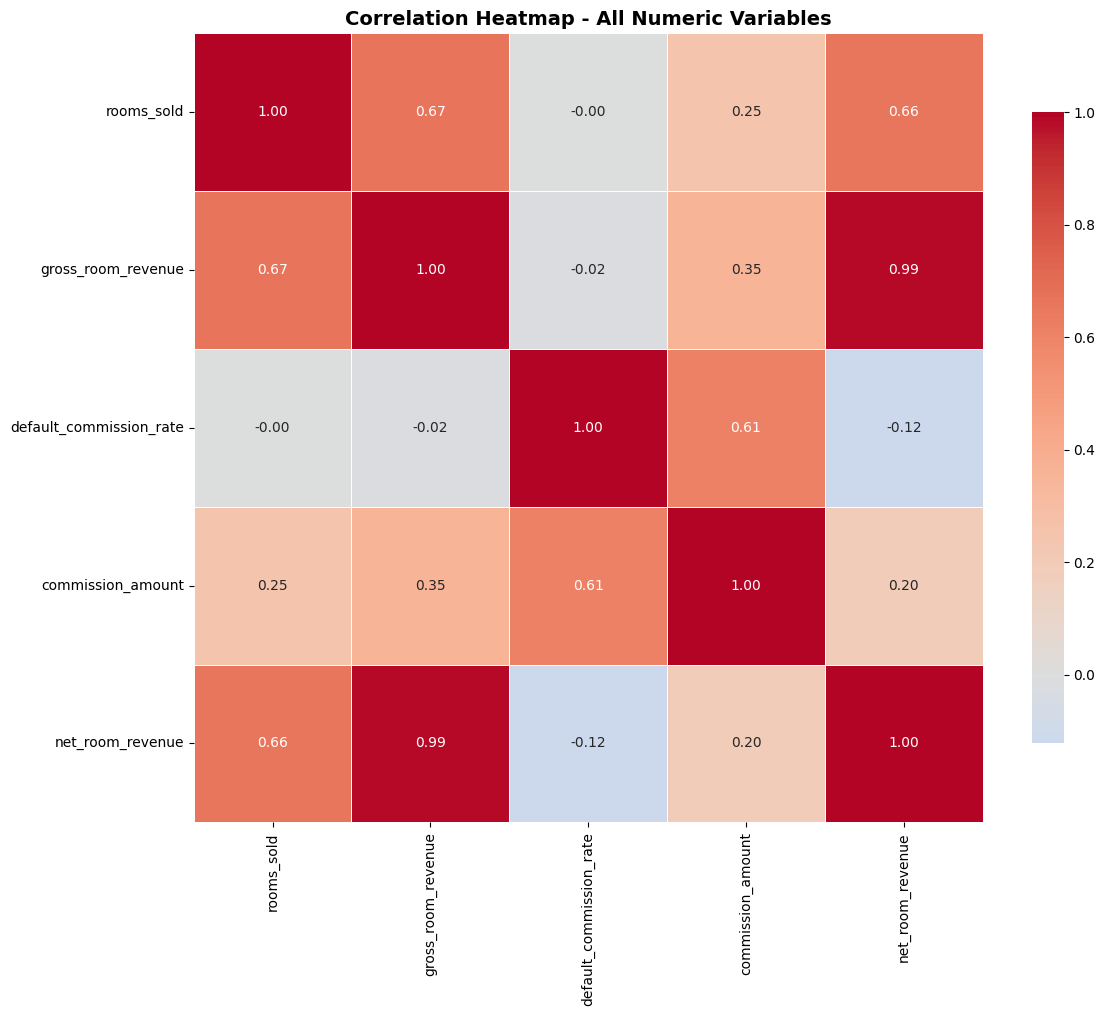



2. PRINCIPAL COMPONENT ANALYSIS (PCA)
--------------------------------------------------

Explained Variance by Principal Components:
  PC1: 53.72% (Cumulative: 53.72%)
  PC2: 31.21% (Cumulative: 84.93%)
  PC3: 8.72% (Cumulative: 93.65%)
  PC4: 6.35% (Cumulative: 100.00%)
  PC5: 0.00% (Cumulative: 100.00%)

Components needed for 95% variance: 4


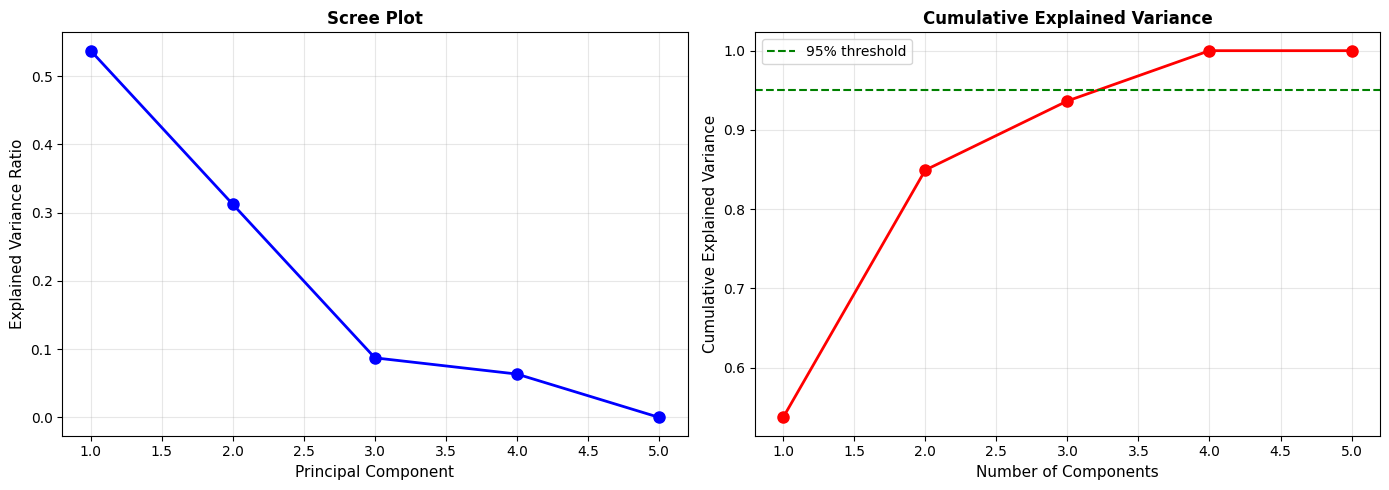


PCA Loadings (First 2 Components):
                           PC1    PC2
rooms_sold               0.815 -0.106
gross_room_revenue       0.965 -0.124
default_commission_rate  0.093  0.920
commission_amount        0.466  0.786
net_room_revenue         0.930 -0.265


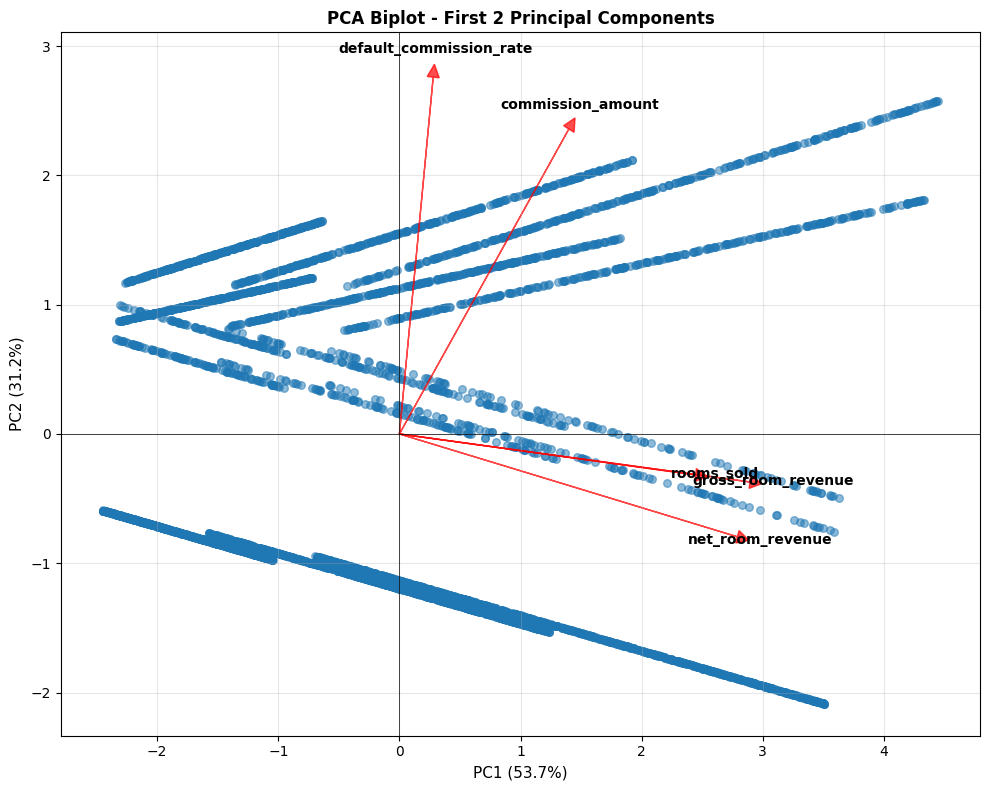



3. CLUSTERING ANALYSIS (K-MEANS)
--------------------------------------------------


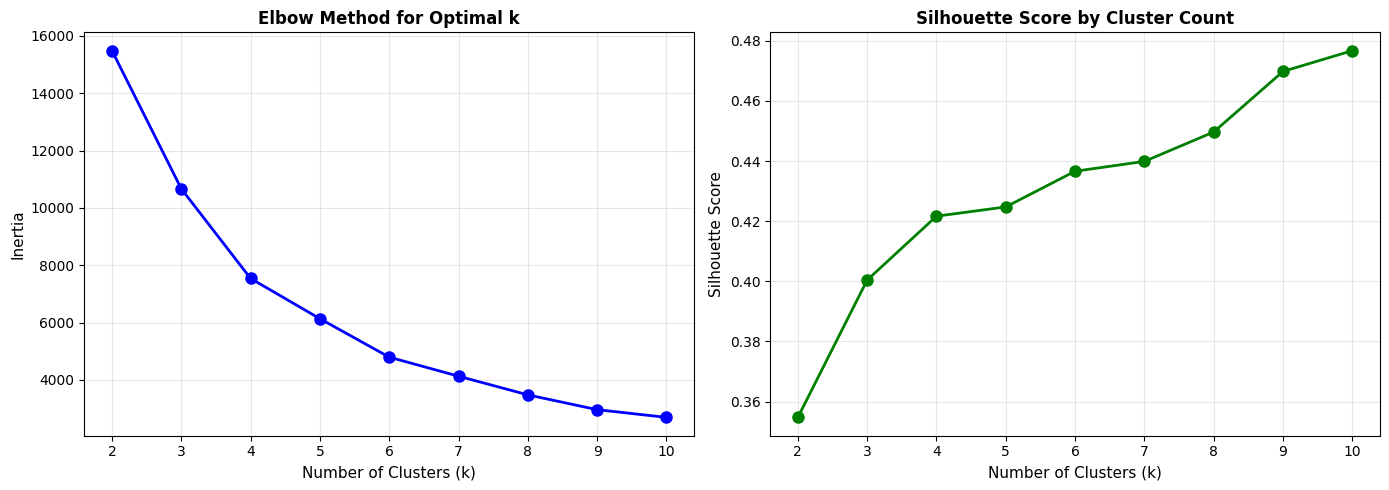


Optimal number of clusters (Silhouette Score): 10
Cluster distribution:
0    433
1    571
2    586
3    561
4    235
5    248
6    376
7    832
8    841
9    317
Name: count, dtype: int64


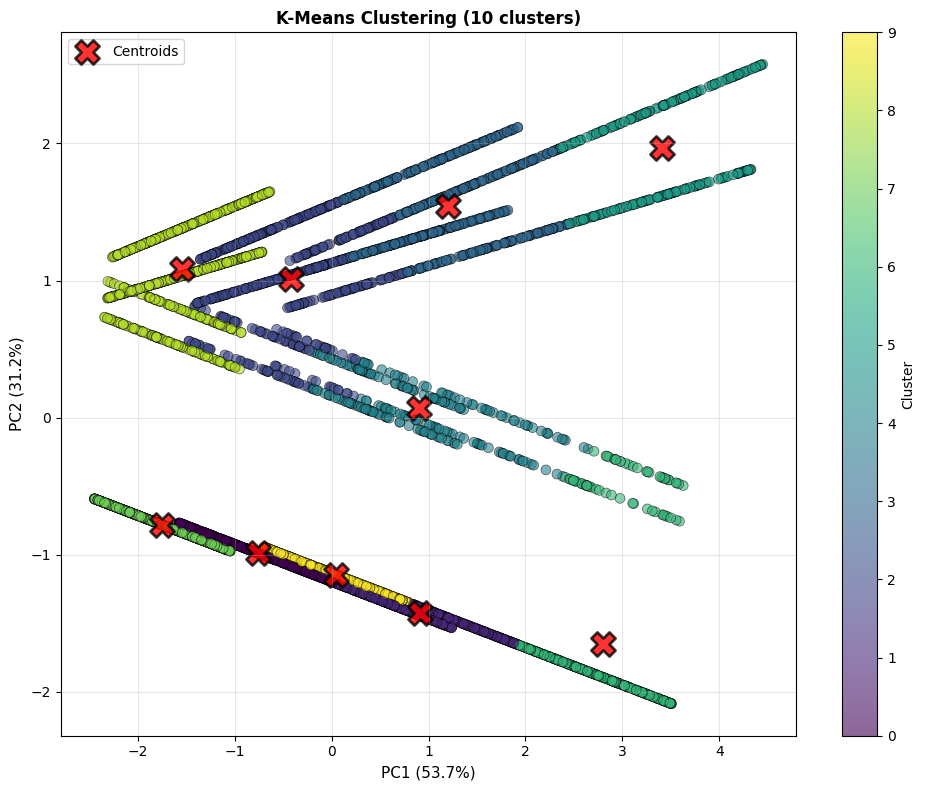



4. HIERARCHICAL CLUSTERING
--------------------------------------------------


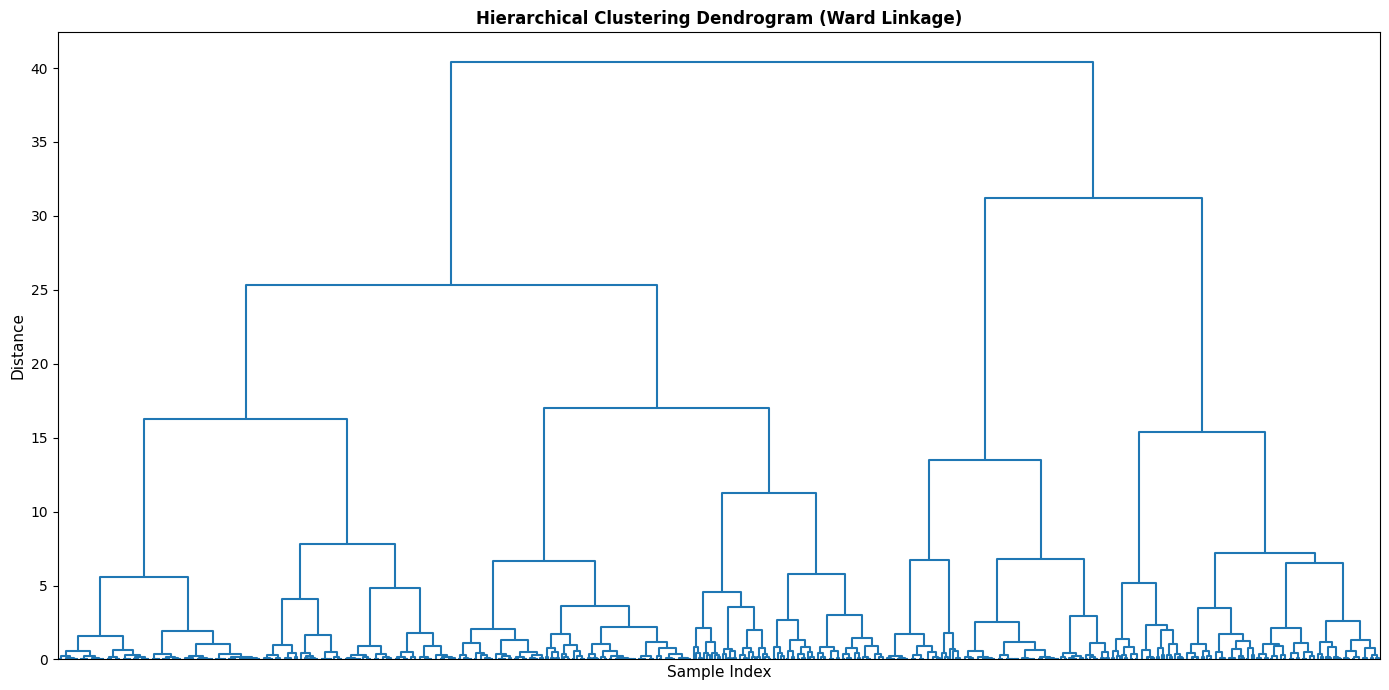

Hierarchical clustering dendrogram generated from 500 samples

Multivariate analysis complete! Check data/result/ for visualizations.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

# Prepare numeric data for multivariate analysis
numeric_cols_analysis = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols_analysis) < 2:
    print("Not enough numeric columns for multivariate analysis")
else:
    print(f"\n=== MULTIVARIATE ANALYSIS ({len(numeric_cols_analysis)} numeric variables) ===\n")
    
    # ===== 1. CORRELATION MATRIX & HEATMAP =====
    print("1. CORRELATION ANALYSIS")
    print("-" * 50)
    
    corr_matrix = df[numeric_cols_analysis].corr()
    print("\nCorrelation Matrix:")
    print(corr_matrix.round(3).to_string())
    
    # Extract strong correlations (|r| > 0.5)
    print("\nStrong Correlations (|r| > 0.5):")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                corr_pairs.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    
    if corr_pairs:
        corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False, key=abs)
        print(corr_pairs_df.to_string(index=False))
    else:
        print("No strong correlations found (|r| > 0.5)")
    
    # Correlation heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap - All Numeric Variables', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{result_dir}/01_correlation_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # ===== 2. PRINCIPAL COMPONENT ANALYSIS (PCA) =====
    print("\n\n2. PRINCIPAL COMPONENT ANALYSIS (PCA)")
    print("-" * 50)
    
    # Prepare data for PCA
    df_numeric = df[numeric_cols_analysis].dropna()
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_numeric)
    
    # Perform PCA
    pca = PCA()
    pca.fit(scaled_data)
    
    # Explained variance
    cumsum_var = np.cumsum(pca.explained_variance_ratio_)
    print(f"\nExplained Variance by Principal Components:")
    for i, (var, cum_var) in enumerate(zip(pca.explained_variance_ratio_[:5], cumsum_var[:5])):
        print(f"  PC{i+1}: {var*100:.2f}% (Cumulative: {cum_var*100:.2f}%)")
    
    # Find number of components for 95% variance
    n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
    print(f"\nComponents needed for 95% variance: {n_components_95}")
    
    # PCA variance plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scree plot
    ax1.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
             pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Principal Component', fontsize=11)
    ax1.set_ylabel('Explained Variance Ratio', fontsize=11)
    ax1.set_title('Scree Plot', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Cumulative variance plot
    ax2.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'ro-', linewidth=2, markersize=8)
    ax2.axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
    ax2.set_xlabel('Number of Components', fontsize=11)
    ax2.set_ylabel('Cumulative Explained Variance', fontsize=11)
    ax2.set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{result_dir}/02_pca_variance.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # PCA component loadings (first 2 components)
    if len(numeric_cols_analysis) >= 2:
        loadings = pca.components_[:2].T * np.sqrt(pca.explained_variance_[:2])
        loadings_df = pd.DataFrame(
            loadings,
            columns=['PC1', 'PC2'],
            index=numeric_cols_analysis
        )
        
        print("\nPCA Loadings (First 2 Components):")
        print(loadings_df.round(3).to_string())
        
        # Biplot
        plt.figure(figsize=(10, 8))
        
        # Project data onto first 2 PCs
        pca_2d = PCA(n_components=2)
        scores = pca_2d.fit_transform(scaled_data)
        
        plt.scatter(scores[:, 0], scores[:, 1], alpha=0.5, s=30)
        
        # Plot loading vectors
        for i, var in enumerate(numeric_cols_analysis):
            plt.arrow(0, 0, loadings_df.iloc[i, 0]*3, loadings_df.iloc[i, 1]*3,
                     head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.7)
            plt.text(loadings_df.iloc[i, 0]*3.2, loadings_df.iloc[i, 1]*3.2, var,
                    fontsize=10, fontweight='bold', ha='center')
        
        plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
        plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
        plt.title('PCA Biplot - First 2 Principal Components', fontsize=12, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
        plt.tight_layout()
        plt.savefig(f"{result_dir}/03_pca_biplot.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    # ===== 3. CLUSTERING ANALYSIS =====
    print("\n\n3. CLUSTERING ANALYSIS (K-MEANS)")
    print("-" * 50)
    
    # Elbow method to find optimal k
    inertias = []
    silhouette_scores = []
    from sklearn.metrics import silhouette_score
    
    K_range = range(2, min(11, len(df_numeric)))
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(scaled_data)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))
    
    # Elbow plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
    ax1.set_ylabel('Inertia', fontsize=11)
    ax1.set_title('Elbow Method for Optimal k', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
    ax2.set_xlabel('Number of Clusters (k)', fontsize=11)
    ax2.set_ylabel('Silhouette Score', fontsize=11)
    ax2.set_title('Silhouette Score by Cluster Count', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{result_dir}/04_clustering_elbow.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Optimal k based on silhouette score
    optimal_k = list(K_range)[np.argmax(silhouette_scores)]
    print(f"\nOptimal number of clusters (Silhouette Score): {optimal_k}")
    
    # Final K-means clustering
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    clusters = kmeans_final.fit_predict(scaled_data)
    
    print(f"Cluster distribution:")
    cluster_counts = pd.Series(clusters).value_counts().sort_index()
    print(cluster_counts)
    
    # Cluster visualization (using first 2 PCA components)
    pca_viz = PCA(n_components=2)
    pca_scores = pca_viz.fit_transform(scaled_data)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(pca_scores[:, 0], pca_scores[:, 1], 
                         c=clusters, cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Plot cluster centers
    centers = pca_viz.transform(kmeans_final.cluster_centers_)
    plt.scatter(centers[:, 0], centers[:, 1], c='red', s=300, alpha=0.8, 
               marker='X', edgecolors='black', linewidth=2, label='Centroids')
    
    plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
    plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
    plt.title(f'K-Means Clustering ({optimal_k} clusters)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, label='Cluster')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{result_dir}/05_kmeans_clustering.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # ===== 4. HIERARCHICAL CLUSTERING =====
    print("\n\n4. HIERARCHICAL CLUSTERING")
    print("-" * 50)
    
    # Sample data if too large (for performance)
    sample_size = min(500, len(df_numeric))
    sample_indices = np.random.choice(len(df_numeric), sample_size, replace=False)
    sample_scaled = scaled_data[sample_indices]
    
    # Linkage matrix
    linkage_matrix = linkage(sample_scaled, method='ward')
    
    # Dendrogram
    plt.figure(figsize=(14, 7))
    dendrogram(linkage_matrix, no_labels=True, color_threshold=0)
    plt.xlabel('Sample Index', fontsize=11)
    plt.ylabel('Distance', fontsize=11)
    plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{result_dir}/06_hierarchical_dendrogram.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Hierarchical clustering dendrogram generated from {sample_size} samples")
    
    print("\n" + "="*50)
    print("Multivariate analysis complete! Check data/result/ for visualizations.")
    print("="*50)

# pattern & trend detection


=== PATTERN & TREND DETECTION ===

Date range: 2025-01-01 00:00:00 to 2026-12-31 00:00:00

1. TEMPORAL TRENDS
--------------------------------------------------

Monthly Aggregation Summary:
  Months covered: 24

  rooms_sold:
    Trend: ↑ Increasing (slope=1.68)
    R² = 0.132

  gross_room_revenue:
    Trend: ↑ Increasing (slope=415.04)
    R² = 0.089

  default_commission_rate:
    Trend: ↑ Increasing (slope=0.08)
    R² = 0.097


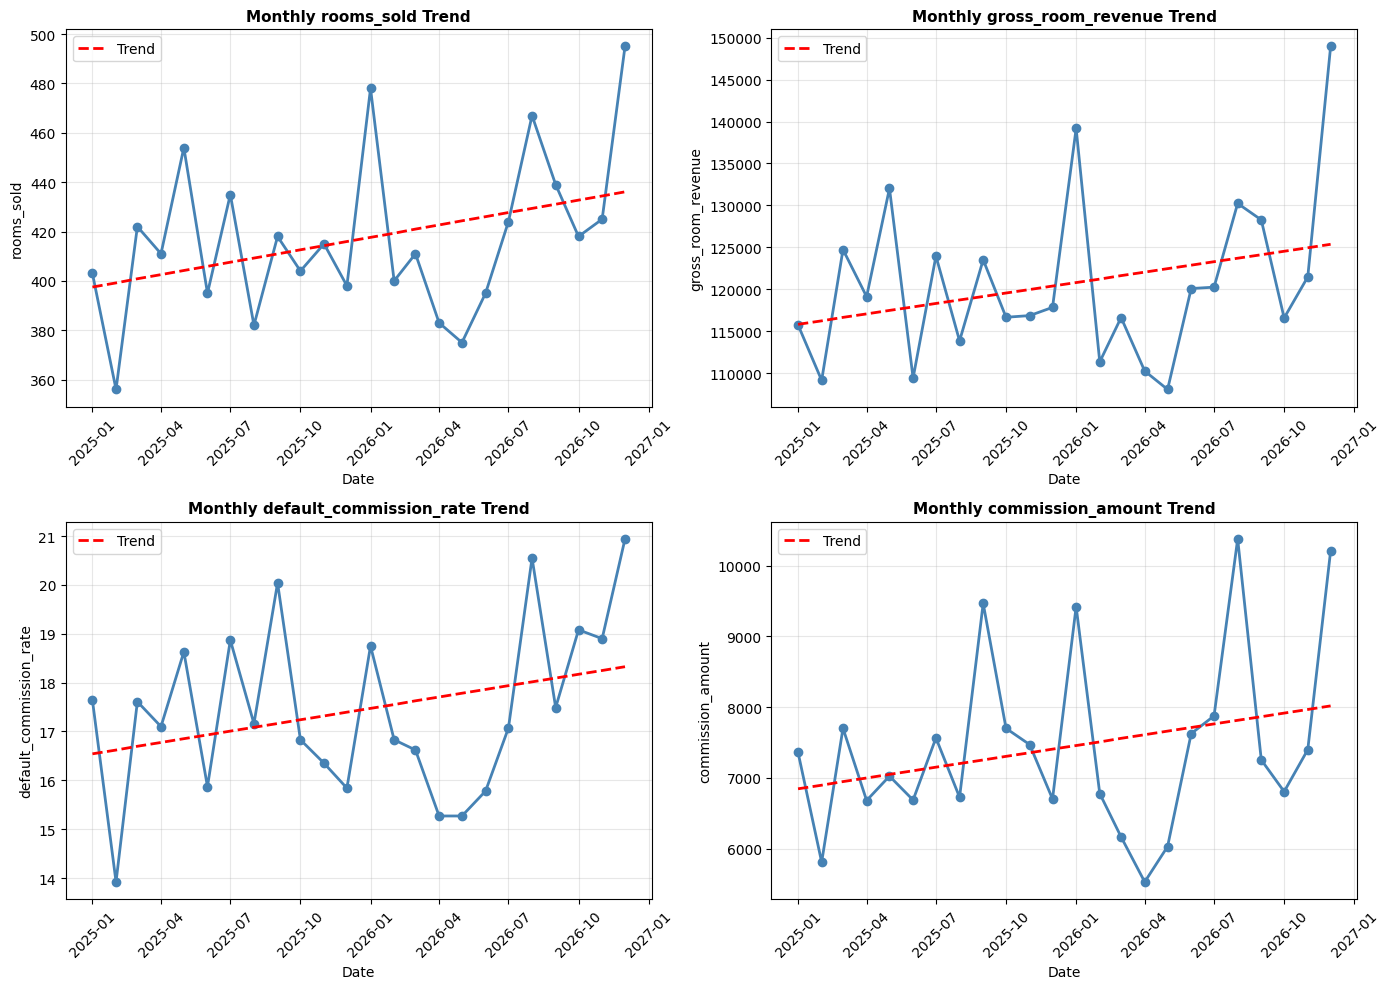



2. SEASONALITY PATTERNS
--------------------------------------------------

Average by Month (Seasonality):
       rooms_sold  gross_room_revenue  default_commission_rate  commission_amount  net_room_revenue     year  month  quarter  week_of_year
month                                                                                                                                     
1            2.03              588.74                     0.08              38.75            549.99  2025.54    1.0      1.0          3.14
2            1.97              574.15                     0.08              32.78            541.36  2025.51    2.0      1.0          7.36
3            1.98              574.66                     0.08              33.02            541.65  2025.51    3.0      1.0         11.43
4            2.01              580.66                     0.08              30.91            549.75  2025.49    4.0      2.0         15.88
5            1.96              567.57                   

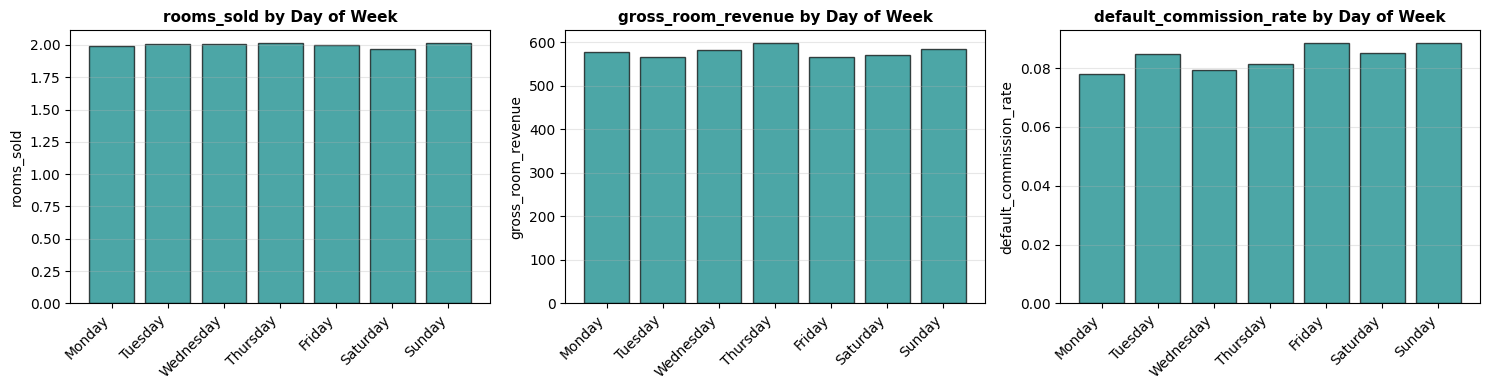



Seasonality Heatmap (Average Revenue by Month & Year):


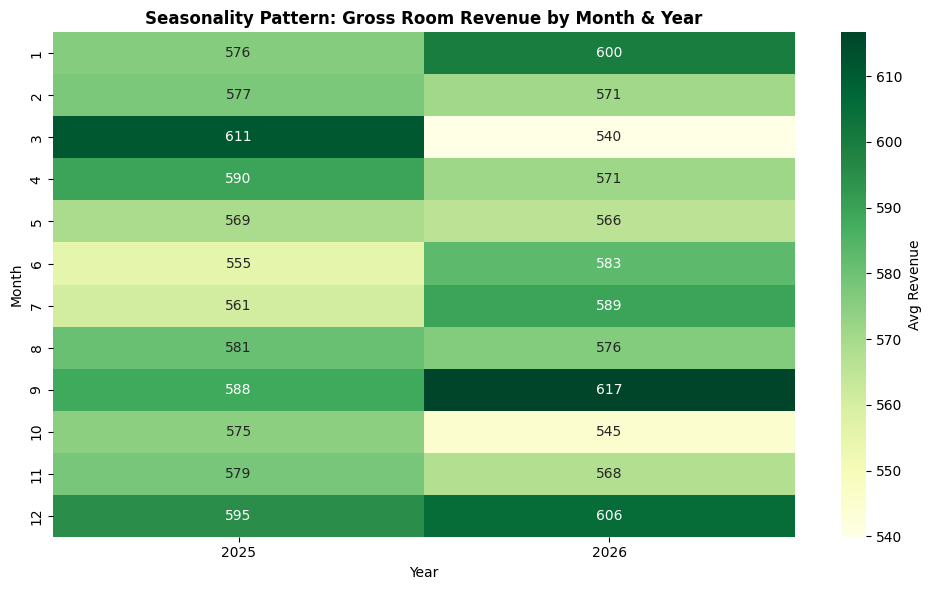



3. ANOMALY & PATTERN DETECTION
--------------------------------------------------

Daily Statistics:

  rooms_sold:
    Mean: 13.72, Std Dev: 5.64
    Outlier days (±2σ): 35
    Top outliers:
      2025-09-12: 32.00 (z-score: 3.24)
      2026-03-02: 31.00 (z-score: 3.06)
      2025-11-06: 30.00 (z-score: 2.89)

  gross_room_revenue:
    Mean: 3970.01, Std Dev: 1788.76
    Outlier days (±2σ): 30
    Top outliers:
      2026-03-02: 10296.43 (z-score: 3.54)
      2025-09-12: 9307.03 (z-score: 2.98)
      2025-03-27: 9239.35 (z-score: 2.95)


Revenue Distribution Insights:

  Top 3 Months (by Revenue):
    2026-12: $148,957.83
    2026-01: $139,175.02
    2025-05: $132,031.30

  Bottom 3 Months (by Revenue):
    2026-05: $108,050.85
    2025-02: $109,133.69
    2025-06: $109,411.78

  Revenue Variance: 33.9%


4. GROWTH PATTERNS
--------------------------------------------------

Yearly Revenue:
  2025: $1,422,845.81
  2026: $1,471,288.22

Year-over-Year Growth:
  2026: ↑ +3.4%


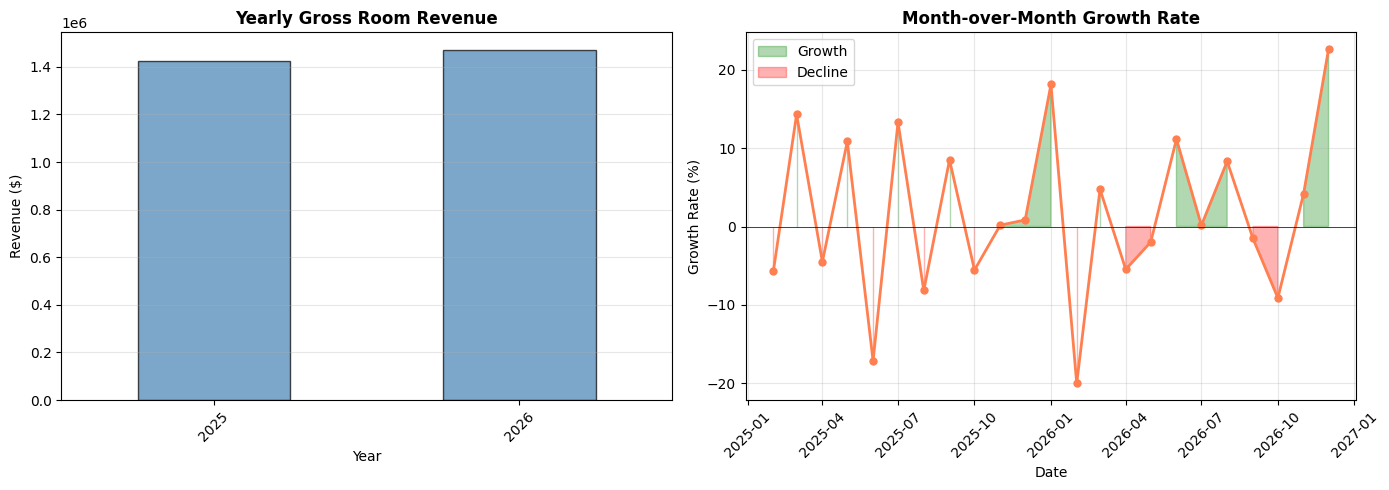


Pattern & Trend Detection complete!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

print("\n=== PATTERN & TREND DETECTION ===\n")

# Ensure date columns are parsed
date_cols = [col for col in df.columns if "date" in col.lower()]
for col in date_cols:
    if df[col].dtype == 'object':
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

# Extract date components for trend analysis
if date_cols:
    main_date_col = date_cols[0]
    df['year'] = df[main_date_col].dt.year
    df['month'] = df[main_date_col].dt.month
    df['quarter'] = df[main_date_col].dt.quarter
    df['day_of_week'] = df[main_date_col].dt.day_name()
    df['week_of_year'] = df[main_date_col].dt.isocalendar().week
    
    print(f"Date range: {df[main_date_col].min()} to {df[main_date_col].max()}")
    
    # ===== 1. TEMPORAL TRENDS =====
    print("\n1. TEMPORAL TRENDS")
    print("-" * 50)
    
    numeric_cols_analysis = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Monthly aggregation
    monthly_data = df.groupby(df[main_date_col].dt.to_period('M'))[numeric_cols_analysis].agg(['mean', 'sum', 'count'])
    monthly_data.index = monthly_data.index.to_timestamp()
    
    print(f"\nMonthly Aggregation Summary:")
    print(f"  Months covered: {len(monthly_data)}")
    
    # Trend analysis for each numeric column
    for col in numeric_cols_analysis[:3]:  # Focus on top 3
        monthly_sum = df.groupby(df[main_date_col].dt.to_period('M'))[col].sum()
        monthly_sum.index = monthly_sum.index.to_timestamp()
        
        # Linear regression for trend
        if len(monthly_sum) > 2:
            X = np.arange(len(monthly_sum)).reshape(-1, 1)
            y = monthly_sum.values
            model = LinearRegression()
            model.fit(X, y)
            slope = model.coef_[0]
            r_squared = model.score(X, y)
            
            trend_direction = "↑ Increasing" if slope > 0 else "↓ Decreasing"
            print(f"\n  {col}:")
            print(f"    Trend: {trend_direction} (slope={slope:.2f})")
            print(f"    R² = {r_squared:.3f}")
    
    # Monthly trend visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    cols_to_plot = [col for col in numeric_cols_analysis if col in df.columns][:4]
    
    for idx, col in enumerate(cols_to_plot):
        monthly_sum = df.groupby(df[main_date_col].dt.to_period('M'))[col].sum()
        monthly_sum.index = monthly_sum.index.to_timestamp()
        
        axes[idx].plot(monthly_sum.index, monthly_sum.values, 'o-', linewidth=2, markersize=6, color='steelblue')
        
        # Add trend line
        X = np.arange(len(monthly_sum)).reshape(-1, 1)
        y = monthly_sum.values
        model = LinearRegression()
        model.fit(X, y)
        trend_line = model.predict(X)
        axes[idx].plot(monthly_sum.index, trend_line, '--', color='red', linewidth=2, label='Trend')
        
        axes[idx].set_title(f'Monthly {col} Trend', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel(col)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].legend()
    
    plt.tight_layout()
    plt.savefig(f"{result_dir}/07_monthly_trends.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # ===== 2. SEASONALITY PATTERNS =====
    print("\n\n2. SEASONALITY PATTERNS")
    print("-" * 50)
    
    # Monthly seasonality (average by month across all years)
    seasonal_pattern = df.groupby('month')[numeric_cols_analysis].mean()
    print("\nAverage by Month (Seasonality):")
    print(seasonal_pattern.round(2).to_string())
    
    # Quarterly patterns
    quarterly_pattern = df.groupby('quarter')[numeric_cols_analysis].mean()
    print("\nAverage by Quarter:")
    print(quarterly_pattern.round(2).to_string())
    
    # Day-of-week patterns (if available)
    if df['day_of_week'].nunique() > 1:
        dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        dow_pattern = df.groupby('day_of_week')[numeric_cols_analysis].mean()
        dow_pattern = dow_pattern.reindex([d for d in dow_order if d in dow_pattern.index])
        
        print("\nAverage by Day of Week:")
        print(dow_pattern.round(2).to_string())
        
        # Day-of-week visualization
        fig, axes = plt.subplots(1, min(3, len(numeric_cols_analysis)), figsize=(15, 4))
        if not isinstance(axes, np.ndarray):
            axes = [axes]
        
        for idx, col in enumerate(numeric_cols_analysis[:len(axes)]):
            dow_data = df.groupby('day_of_week')[col].mean()
            dow_data = dow_data.reindex([d for d in dow_order if d in dow_data.index])
            
            axes[idx].bar(range(len(dow_data)), dow_data.values, color='teal', alpha=0.7, edgecolor='black')
            axes[idx].set_xticks(range(len(dow_data)))
            axes[idx].set_xticklabels(dow_data.index, rotation=45, ha='right')
            axes[idx].set_title(f'{col} by Day of Week', fontsize=11, fontweight='bold')
            axes[idx].set_ylabel(col)
            axes[idx].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(f"{result_dir}/08_dayofweek_patterns.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    # Seasonality heatmap (month-year)
    if 'year' in df.columns and 'month' in df.columns:
        print("\n\nSeasonality Heatmap (Average Revenue by Month & Year):")
        
        if 'gross_room_revenue' in numeric_cols_analysis:
            pivot_seasonal = df.pivot_table(
                values='gross_room_revenue',
                index='month',
                columns='year',
                aggfunc='mean'
            )
            
            plt.figure(figsize=(10, 6))
            sns.heatmap(pivot_seasonal, annot=True, fmt='.0f', cmap='YlGn', cbar_kws={'label': 'Avg Revenue'})
            plt.title('Seasonality Pattern: Gross Room Revenue by Month & Year', fontsize=12, fontweight='bold')
            plt.xlabel('Year')
            plt.ylabel('Month')
            plt.tight_layout()
            plt.savefig(f"{result_dir}/09_seasonality_heatmap.png", dpi=300, bbox_inches='tight')
            plt.show()
    
    # ===== 3. ANOMALY & PATTERN DETECTION =====
    print("\n\n3. ANOMALY & PATTERN DETECTION")
    print("-" * 50)
    
    # Identify unusual days (outliers)
    daily_data = df.groupby(df[main_date_col].dt.date)[numeric_cols_analysis].sum()
    
    print("\nDaily Statistics:")
    for col in numeric_cols_analysis[:2]:
        daily_values = daily_data[col]
        mean_val = daily_values.mean()
        std_val = daily_values.std()
        
        # 2-sigma outliers
        outliers = daily_values[(daily_values > mean_val + 2*std_val) | (daily_values < mean_val - 2*std_val)]
        
        print(f"\n  {col}:")
        print(f"    Mean: {mean_val:.2f}, Std Dev: {std_val:.2f}")
        print(f"    Outlier days (±2σ): {len(outliers)}")
        
        if len(outliers) > 0:
            print(f"    Top outliers:")
            for date, val in outliers.nlargest(3).items():
                z_score = (val - mean_val) / std_val
                print(f"      {date}: {val:.2f} (z-score: {z_score:.2f})")
    
    # Distribution by time period
    print("\n\nRevenue Distribution Insights:")
    
    # Best and worst performing periods
    if 'gross_room_revenue' in numeric_cols_analysis:
        monthly_revenue = df.groupby(df[main_date_col].dt.to_period('M'))['gross_room_revenue'].sum()
        
        print(f"\n  Top 3 Months (by Revenue):")
        for period, revenue in monthly_revenue.nlargest(3).items():
            print(f"    {period}: ${revenue:,.2f}")
        
        print(f"\n  Bottom 3 Months (by Revenue):")
        for period, revenue in monthly_revenue.nsmallest(3).items():
            print(f"    {period}: ${revenue:,.2f}")
        
        revenue_variance = (monthly_revenue.max() - monthly_revenue.min()) / monthly_revenue.mean() * 100
        print(f"\n  Revenue Variance: {revenue_variance:.1f}%")
    
    # ===== 4. GROWTH PATTERNS =====
    print("\n\n4. GROWTH PATTERNS")
    print("-" * 50)
    
    if 'gross_room_revenue' in numeric_cols_analysis:
        # Year-over-year growth
        yearly_revenue = df.groupby('year')['gross_room_revenue'].sum()
        
        print("\nYearly Revenue:")
        for year, revenue in yearly_revenue.items():
            print(f"  {year}: ${revenue:,.2f}")
        
        if len(yearly_revenue) > 1:
            yoy_growth = yearly_revenue.pct_change() * 100
            print("\nYear-over-Year Growth:")
            for year, growth in yoy_growth.items():
                if pd.notna(growth):
                    direction = "↑" if growth > 0 else "↓"
                    print(f"  {year}: {direction} {growth:+.1f}%")
        
        # Growth trend visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Yearly trend
        yearly_revenue.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black', alpha=0.7)
        ax1.set_title('Yearly Gross Room Revenue', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Revenue ($)')
        ax1.set_xlabel('Year')
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.tick_params(axis='x', rotation=45)
        
        # Monthly growth rate (MoM)
        monthly_revenue = df.groupby(df[main_date_col].dt.to_period('M'))['gross_room_revenue'].sum()
        monthly_revenue.index = monthly_revenue.index.to_timestamp()
        mom_growth = monthly_revenue.pct_change() * 100
        
        ax2.plot(mom_growth.index, mom_growth.values, 'o-', color='coral', linewidth=2, markersize=5)
        ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax2.fill_between(mom_growth.index, mom_growth.values, 0, where=(mom_growth >= 0), alpha=0.3, color='green', label='Growth')
        ax2.fill_between(mom_growth.index, mom_growth.values, 0, where=(mom_growth < 0), alpha=0.3, color='red', label='Decline')
        ax2.set_title('Month-over-Month Growth Rate', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Growth Rate (%)')
        ax2.set_xlabel('Date')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.savefig(f"{result_dir}/10_growth_patterns.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    print("\n" + "="*50)
    print("Pattern & Trend Detection complete!")
    print("="*50)

else:
    print("No date columns found. Skipping temporal analysis.")
    print("\nNote: Add date columns (like 'booking_date') for full pattern detection.")